In [1]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path: sys.path.insert(0, project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_insurance_data
from src.modeling import prepare_modeling_data, train_stage_1_classifier, train_stage_2_regressor

# Load data state
df = load_insurance_data('../data/cleaned_insurance_data.csv')
clean_df, X = prepare_modeling_data(df)
print(f"Feature matrix generated. Rows: {X.shape[0]}, Columns: {X.shape[1]}")

Feature matrix generated. Rows: 10000, Columns: 13


In [2]:
# Stage 1: Likelihood of Claim
y_cls = clean_df['IsClaimant']
clf_model, clf_metrics, X_test, y_test = train_stage_1_classifier(X, y_cls)
print("Stage 1 Classifier Metrics:", clf_metrics)

# Stage 2: Claim Severity (Only rows where TotalClaims > 0)
claimant_mask = clean_df['TotalClaims'] > 0
X_sev = X[claimant_mask]
y_sev = clean_df[claimant_mask]['TotalClaims']

reg_model, reg_metrics = train_stage_2_regressor(X_sev, y_sev)
print("Stage 2 Regressor Metrics:", reg_metrics)

Stage 1 Classifier Metrics: {'ROC_AUC': 0.7648624052671376, 'Log_Loss': 0.365782235248884}
Stage 2 Regressor Metrics: {'MAE': 3845.54579635138, 'R2': 0.2088497801861714}


/tmp/ipykernel_130520/1012268272.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_profiles, x='Gender_Male', y='Optimized_Pure_Premium', palette='Set2')


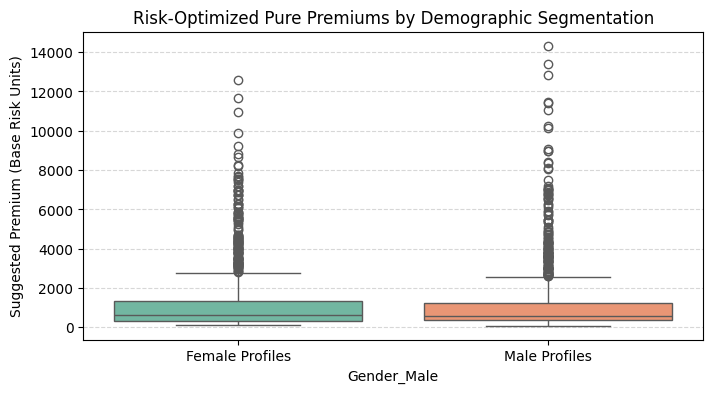

In [3]:
# Predict values for our test matrix
test_profiles = X_test.copy()
test_profiles['Predicted_Probability'] = clf_model.predict_proba(X_test)[:, 1]
test_profiles['Predicted_Severity'] = reg_model.predict(X_test)

# Calculate Pure Premium (Risk Premium)
test_profiles['Optimized_Pure_Premium'] = test_profiles['Predicted_Probability'] * test_profiles['Predicted_Severity']

# Re-attach original demographics for business insight generation
original_indices = test_profiles.index
test_profiles['Gender_Male'] = clean_df.loc[original_indices, 'Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Visualize Premium optimization mapping
plt.figure(figsize=(8, 4))
sns.boxplot(data=test_profiles, x='Gender_Male', y='Optimized_Pure_Premium', palette='Set2')
plt.xticks([0, 1], ['Female Profiles', 'Male Profiles'])
plt.title('Risk-Optimized Pure Premiums by Demographic Segmentation')
plt.ylabel('Suggested Premium (Base Risk Units)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()